# Series

In [1]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt
dictionary={'Neckarwestheim':1269,
            'Isar 2':1365,
            'Emsland':1290}
s=pd.Series(dictionary)
s

Neckarwestheim    1269
Isar 2            1365
Emsland           1290
dtype: int64

In [2]:
dictionary

{'Neckarwestheim': 1269, 'Isar 2': 1365, 'Emsland': 1290}

In [3]:
np.log(s)/s**.5

Neckarwestheim    0.200600
Isar 2            0.195391
Emsland           0.199418
dtype: float64

In [4]:
s.index

Index(['Neckarwestheim', 'Isar 2', 'Emsland'], dtype='str')

In [5]:
s.loc['Isar 2']

np.int64(1365)

In [6]:
s.iloc[2]

np.int64(1290)

In [7]:
s.loc[['Neckarwestheim','Emsland']]

Neckarwestheim    1269
Emsland           1290
dtype: int64

In [8]:
s.iloc[:2]

Neckarwestheim    1269
Isar 2            1365
dtype: int64

In [9]:
type(s.values)

numpy.ndarray

# Dataframe

In [10]:
data={'capacity':[1269,1365,1290],
      'type':['PWR','PWR','PWR'],
      'start_year':[1989,1988,1988],
      'end_year':[np.nan,np.nan,np.nan]}
df=pd.DataFrame(data,index=['Neckarwestheim','Isar 2','Emsland'])
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,NaN
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,NaN


In [11]:
df.min()

capacity      1269
type           PWR
start_year    1988
end_year       NaN
dtype: object

In [12]:
df.mean(numeric_only=True)

capacity      1308.000000
start_year    1988.333333
end_year              NaN
dtype: float64

In [13]:
df.describe()

,capacity,start_year,end_year
count,3.000000,3.000000,0.0
mean,1308.000000,1988.333333,NaN
std,50.467812,0.577350,NaN
min,1269.000000,1988.000000,NaN
25%,1279.500000,1988.000000,NaN
50%,1290.000000,1988.000000,NaN
75%,1327.500000,1988.500000,NaN
max,1365.000000,1989.000000,NaN


In [14]:
df['capacity']

Neckarwestheim    1269
Isar 2            1365
Emsland           1290
Name: capacity, dtype: int64

In [15]:
df.end_year

Neckarwestheim   NaN
Isar 2           NaN
Emsland          NaN
Name: end_year, dtype: float64

In [16]:
df.loc['Emsland']

capacity      1290
type           PWR
start_year    1988
end_year       NaN
Name: Emsland, dtype: object

In [17]:
df.iloc[2]

capacity      1290
type           PWR
start_year    1988
end_year       NaN
Name: Emsland, dtype: object

In [18]:
df.loc['Emsland','start_year']

np.int64(1988)

In [19]:
df.loc[['Emsland','Neckarwestheim'],
       ['start_year','end_year']]

,start_year,end_year
Emsland,1988,NaN
Neckarwestheim,1989,NaN


In [20]:
df.capacity*.8

Neckarwestheim    1015.2
Isar 2            1092.0
Emsland           1032.0
Name: capacity, dtype: float64

In [21]:
df['reduced_capacity']=df.capacity*.8
df

,capacity,type,start_year,end_year,reduced_capacity
Neckarwestheim,1269,PWR,1989,NaN,1015.2
Isar 2,1365,PWR,1988,NaN,1092.0
Emsland,1290,PWR,1988,NaN,1032.0


# Cleaning Data

In [22]:
df=df.drop('reduced_capacity',axis='columns')
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,NaN
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,NaN


In [23]:
df.dropna(axis=1,
          how='any')

,capacity,type,start_year
Neckarwestheim,1269,PWR,1989
Isar 2,1365,PWR,1988
Emsland,1290,PWR,1988


In [24]:
df.loc['Emsland','end_year']=2023
df.loc['Neckarwestheim','end_year']=2026
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,2026.0
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,2023.0


In [25]:
df['end_year']=df['end_year'].ffill()
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,2026.0
Isar 2,1365,PWR,1988,2026.0
Emsland,1290,PWR,1988,2023.0


In [26]:
df['x']=np.nan
df['y']=np.nan
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,1988,2026.0,NaN,NaN
Emsland,1290,PWR,1988,2023.0,NaN,NaN


In [27]:
df.rename(columns=dict(x='lat',
                       y='lon'))

,capacity,type,start_year,end_year,lat,lon
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,1988,2026.0,NaN,NaN
Emsland,1290,PWR,1988,2023.0,NaN,NaN


In [28]:
df.replace({'PWR':'Pressurized water reactor'})

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,Pressurized water reactor,1989,2026.0,NaN,NaN
Isar 2,1365,Pressurized water reactor,1988,2026.0,NaN,NaN
Emsland,1290,Pressurized water reactor,1988,2023.0,NaN,NaN


In [29]:
df.loc['Isar 2','start_year']=2000
df.loc['Emsland','capacity']+=10
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,2000,2026.0,NaN,NaN
Emsland,1300,PWR,1988,2023.0,NaN,NaN


In [30]:
operational=['Neckarwestheim','Isar 2','Emsland']
df.loc[operational,'y']=[49.04,48.61,52.47]
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Emsland,1300,PWR,1988,2023.0,NaN,52.47


# Combining Datasets

In [31]:
data={'capacity':[1288,1360,1326],
      'type':['BWR','PWR','PWR'],
      'start_year':[1985,1985,1986],
      'end_year':[2021,2021,2021],
      'x':[10.4,9.41,9.35],
      'y':[48.51,52.03,53.85]}
df2=pd.DataFrame(data,index=['Gundremmingen','Grohnde','Brokdorf'])
df2

,capacity,type,start_year,end_year,x,y
Gundremmingen,1288,BWR,1985,2021,10.40,48.51
Grohnde,1360,PWR,1985,2021,9.41,52.03
Brokdorf,1326,PWR,1986,2021,9.35,53.85


In [32]:
df=pd.concat([df,df2])
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Emsland,1300,PWR,1988,2023.0,NaN,52.47
Gundremmingen,1288,BWR,1985,2021.0,10.40,48.51
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85


# Sorting, Filtering Data

In [33]:
df.sort_index()

,capacity,type,start_year,end_year,x,y
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85
Emsland,1300,PWR,1988,2023.0,NaN,52.47
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Gundremmingen,1288,BWR,1985,2021.0,10.40,48.51
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04


In [34]:
df.capacity>1300

Neckarwestheim    False
Isar 2             True
Emsland           False
Gundremmingen     False
Grohnde            True
Brokdorf           True
Name: capacity, dtype: bool

In [35]:
df[df.capacity>1300]

,capacity,type,start_year,end_year,x,y
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85


In [36]:
df[(df.capacity>1300)&(df.start_year>=1988)]

,capacity,type,start_year,end_year,x,y
Isar 2,1365,PWR,2000,2026.0,NaN,48.61


In [37]:
df.query('start_year==1988')

,capacity,type,start_year,end_year,x,y
Emsland,1300,PWR,1988,2023.0,NaN,52.47


In [38]:
threshold=1300
df.query('start_year==1988 and capacity>@threshold')

,capacity,type,start_year,end_year,x,y


# Applying Functions

In [39]:
def normalise(s):
    return s/df.capacity.max()
df.capacity.apply(normalise)

Neckarwestheim    0.929670
Isar 2            1.000000
Emsland           0.952381
Gundremmingen     0.943590
Grohnde           0.996337
Brokdorf          0.971429
Name: capacity, dtype: float64

# Plotting

<Axes: xlabel='start_year', ylabel='capacity'>

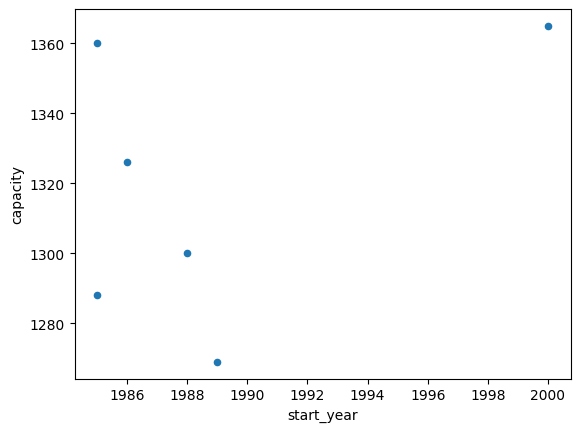

In [40]:
df.plot(kind='scatter',
        x='start_year',
        y='capacity')

Text(0.5, 0, 'Capacity (MW)')

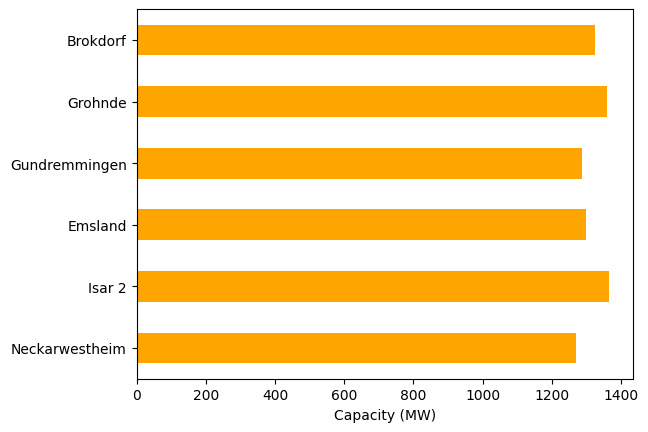

In [41]:
df.capacity.plot.barh(color='orange')
plt.xlabel('Capacity (MW)')

# Time Indexes

In [42]:
time=pd.date_range(start='2021-01-01',
                   end='2023-01-01',
                   freq='D')
time.dayofyear

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       357, 358, 359, 360, 361, 362, 363, 364, 365,   1],
      dtype='int32', length=731)

In [43]:
values=np.sin(2*np.pi*time.dayofyear/365)
values

Index([ 0.017213356155834685,   0.03442161162274574,  0.051619667223253764,
         0.06880242680231986,   0.08596479873744647,   0.10310169744743485,
          0.1202080448993527,   0.13727877211326478,   0.15430882066428117,
          0.1712931441814776,
       ...
        -0.13727877211326517,  -0.12020804489935275,  -0.10310169744743544,
         -0.0859647987374467,  -0.06880242680232064,  -0.05161966722325418,
       -0.034421611622745804,  -0.01721335615583528, 6.432490598706546e-16,
        0.017213356155834685],
      dtype='float64', length=731)

In [44]:
ts=pd.Series(values,index=time)
ts

2021-01-01    1.721336e-02
2021-01-02    3.442161e-02
2021-01-03    5.161967e-02
2021-01-04    6.880243e-02
2021-01-05    8.596480e-02
                  ...     
2022-12-28   -5.161967e-02
2022-12-29   -3.442161e-02
2022-12-30   -1.721336e-02
2022-12-31    6.432491e-16
2023-01-01    1.721336e-02
Freq: D, Length: 731, dtype: float64

<Axes: >

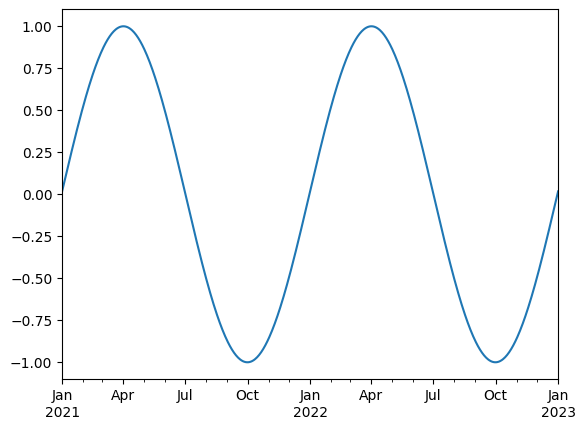

In [45]:
ts.plot()

<Axes: >

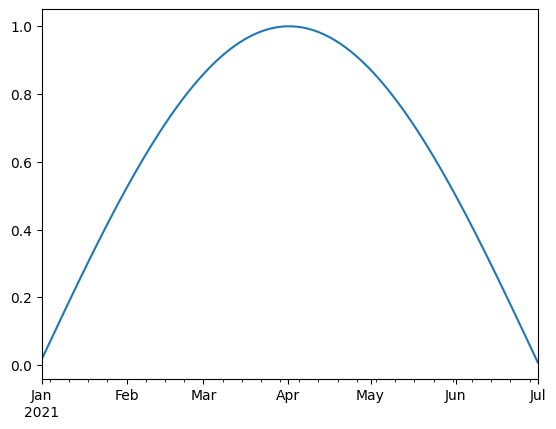

In [46]:
ts.loc['2021-01-01':'2021-07-01'].plot()

<Axes: >

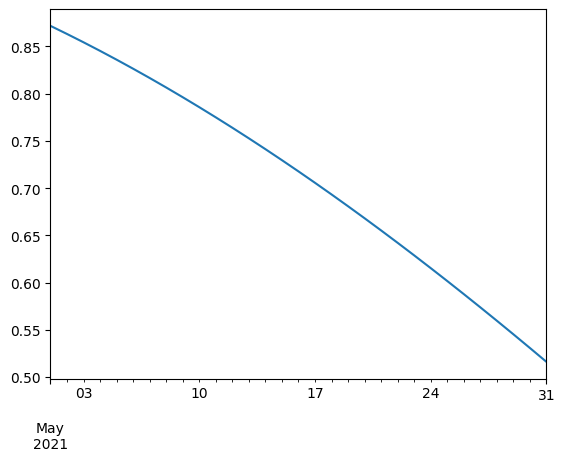

In [47]:
ts.loc['2021-05'].plot()

In [48]:
ts.index.month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12,  1],
      dtype='int32', length=731)

In [49]:
ts.index.weekday

Index([4, 5, 6, 0, 1, 2, 3, 4, 5, 6,
       ...
       4, 5, 6, 0, 1, 2, 3, 4, 5, 6],
      dtype='int32', length=731)

In [50]:
ts.resample('12h').mean().interpolate()

2021-01-01 00:00:00    1.721336e-02
2021-01-01 12:00:00    2.581748e-02
2021-01-02 00:00:00    3.442161e-02
2021-01-02 12:00:00    4.302064e-02
2021-01-03 00:00:00    5.161967e-02
                           ...     
2022-12-30 00:00:00   -1.721336e-02
2022-12-30 12:00:00   -8.606678e-03
2022-12-31 00:00:00    6.432491e-16
2022-12-31 12:00:00    8.606678e-03
2023-01-01 00:00:00    1.721336e-02
Freq: 12h, Length: 1461, dtype: float64

<Axes: >

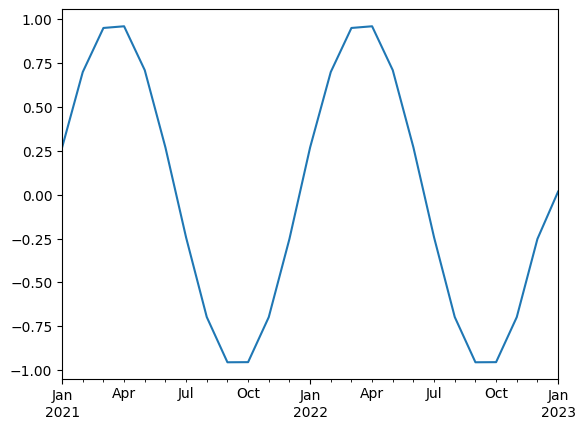

In [51]:
ts.resample('ME').mean().plot()

# Reading, Writing Files

In [52]:
fn='data/powerplants.csv'
df=pd.read_csv(fn,index_col=0)
df.iloc[:5,
        :10]

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut
id,,,,,,,,,,
0,Illwerke Vkw Rodundwerk,Hydro,Reservoir,Store,Austria,495.0,0.75,1943.0,2011.0,NaN
1,Obervermuntwerk Maschine Turbine,Hydro,Pumped Storage,Storage,Austria,380.0,0.75,1943.0,2018.0,NaN
2,Coche,Hydro,Pumped Storage,Store,France,384.0,NaN,1970.0,2019.0,NaN
3,Cheylas,Hydro,Pumped Storage,Store,France,485.0,NaN,1970.0,NaN,NaN
4,Roncovalgrande,Hydro,Pumped Storage,Store,Italy,1000.0,NaN,1970.0,NaN,NaN


In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 158548 entries, 0 to 159062
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Name                 158548 non-null  str    
 1   Fueltype             158548 non-null  str    
 2   Technology           106116 non-null  str    
 3   Set                  158169 non-null  str    
 4   Country              158548 non-null  str    
 5   Capacity             158514 non-null  float64
 6   Efficiency           510 non-null     float64
 7   DateIn               153762 non-null  float64
 8   DateRetrofit         2553 non-null    float64
 9   DateOut              4720 non-null    float64
 10  lat                  158548 non-null  float64
 11  lon                  158548 non-null  float64
 12  Duration             1853 non-null    float64
 13  Volume_Mm3           1762 non-null    float64
 14  DamHeight_m          2010 non-null    float64
 15  StorageCapacity_MWh  2402 non-nul

In [54]:
df.describe()

,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh
count,158514.000000,510.000000,153762.000000,2553.000000,4720.000000,158548.000000,158548.000000,1853.000000,1762.000000,2010.000000,2.402000e+03
mean,9.274917,0.491218,2012.376615,1986.929886,2021.662500,50.861350,9.790635,466.292583,218.832387,188.112955,2.788792e+04
std,78.762795,0.176591,12.461305,25.376000,5.554816,3.079584,4.059053,1140.727999,1080.085635,254.969851,1.775205e+05
min,0.010000,0.191434,1898.000000,1899.000000,1969.000000,32.647300,-51.721900,0.000005,0.001600,-99.000000,1.000000e-05
25%,0.200000,0.363954,2009.000000,1969.000000,2021.000000,49.181924,8.101518,1.280000,4.250000,34.000000,7.060000e-01
50%,0.500000,0.399300,2013.000000,1994.000000,2022.000000,51.261212,9.804157,2.088000,23.400000,94.600000,9.340000e+00
75%,2.100000,0.588824,2020.000000,2008.000000,2024.000000,52.624376,11.896953,212.841530,112.150000,253.025000,1.142490e+03
max,5400.000000,0.917460,2040.000000,2020.000000,2050.000000,71.012300,39.655350,16840.000000,25810.000000,3051.460000,4.869834e+06


In [55]:
df.to_csv('data/tmp.csv')
df

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
0,Illwerke Vkw Rodundwerk,Hydro,Reservoir,Store,Austria,495.0,0.75,1943.0,2011.0,NaN,47.085032,9.880116,588.383838,2.240000,353.00,291250.000000,"{nan, nan, nan, nan, nan}","{'MASTR': {'MASTR-SEE952262880046', 'MASTR-SEE..."
1,Obervermuntwerk Maschine Turbine,Hydro,Pumped Storage,Storage,Austria,380.0,0.75,1943.0,2018.0,NaN,46.935290,10.059950,71.573684,35.630769,291.00,27198.000000,"{nan, nan}","{'MASTR': {'MASTR-SEE926367113644', 'MASTR-SEE..."
2,Coche,Hydro,Pumped Storage,Store,France,384.0,NaN,1970.0,2019.0,NaN,45.496800,6.510300,2.906250,2.100000,34.00,930.000000,{nan},"{'GEM': {'G100000601653'}, 'JRC': {'JRC-H134'}..."
3,Cheylas,Hydro,Pumped Storage,Store,France,485.0,NaN,1970.0,NaN,NaN,45.386500,6.001300,5.800000,4.800000,245.00,2900.000000,{nan},"{'GEM': {'G100000601652'}, 'JRC': {'JRC-H63'},..."
4,Roncovalgrande,Hydro,Pumped Storage,Store,Italy,1000.0,NaN,1970.0,NaN,NaN,46.069400,8.732400,17.421260,10.000000,736.25,17700.000000,{nan},"{'GEM': {'G100000602249'}, 'JRC': {'JRC-H15'},..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159058,Stramentizzo San Floriano,Hydro,Reservoir,Store,Italy,71.3,NaN,NaN,NaN,NaN,46.290466,11.245401,218.720806,11.500000,572.00,15594.793500,{nan},{'JRC': {'JRC-H3737'}}
159059,Taloro Deg Salto Benzone,Hydro,Reservoir,Store,Italy,32.7,NaN,NaN,NaN,NaN,40.127148,9.140644,272.313988,20.190000,241.00,8904.667391,"{nan, nan}","{'JRC': {'JRC-H3681', 'JRC-H3692'}}"
159060,Valina Ca Zul,Hydro,Reservoir,Store,Italy,8.0,NaN,NaN,NaN,NaN,46.294781,12.711214,325.978125,11.000000,100.00,2607.825000,{nan},{'JRC': {'JRC-H3738'}}


# Grouping, Aggregation

In [56]:
grouped=df.groupby('Country').Capacity.sum()
grouped.sort_values(ascending=False).head(10)

Country
Germany           326960.298047
United Kingdom    161132.840000
France            154211.172001
Spain             139610.514800
Italy             104771.038000
Poland             60847.866738
Ukraine            57548.700000
Sweden             51995.322323
Netherlands        42405.100000
Norway             40624.110000
Name: Capacity, dtype: float64

In [57]:
capacities=df.groupby(['Country','Fueltype']).Capacity.sum()
capacities

Country         Fueltype     
Albania         Hydro             2079.366
                Solar              394.500
                Wind               234.000
Austria         Battery             40.320
                Hard Coal         1471.000
                                   ...    
United Kingdom  Other               35.000
                Solar            12089.700
                Solid Biomass     4154.200
                Waste             1948.150
                Wind             37802.300
Name: Capacity, Length: 327, dtype: float64

In [58]:
capacities.index[:5]

MultiIndex([('Albania',     'Hydro'),
            ('Albania',     'Solar'),
            ('Albania',      'Wind'),
            ('Austria',   'Battery'),
            ('Austria', 'Hard Coal')],
           names=['Country', 'Fueltype'])

In [59]:
type(capacities.index)

pandas.MultiIndex

In [60]:
df.nsmallest(10,'Capacity')

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
18935,Balance,Hydrogen Storage,NaN,Store,Finland,0.01,NaN,NaN,NaN,NaN,64.000000,26.000000,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65017'}}
19011,Dresden,Hydrogen Storage,NaN,Store,Germany,0.01,NaN,NaN,NaN,NaN,51.050100,13.738300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65118'}}
19077,From The Sun Brunate,Hydrogen Storage,NaN,Store,Italy,0.01,NaN,NaN,NaN,NaN,45.823300,9.094200,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65064'}}
19078,Fronius Energy Cell Self Sufficient House,Hydrogen Storage,NaN,Store,Austria,0.01,NaN,NaN,NaN,NaN,48.208300,14.038300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65051'}}
19183,Laboratory System At Ife Kjeller Pahse,Hydrogen Storage,NaN,Store,Norway,0.01,NaN,NaN,NaN,NaN,60.223611,11.033333,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65033'}}
19289,Primolyzer,Hydrogen Storage,NaN,Store,Denmark,0.01,NaN,NaN,NaN,NaN,56.263900,9.501800,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65078'}}
19298,Rabh,Hydrogen Storage,NaN,Store,United Kingdom,0.01,NaN,NaN,NaN,NaN,50.719300,-1.880400,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65088'}}
19304,Regenerativer Energipark Ostfalia Hybrid Renew...,Hydrogen Storage,NaN,Store,Germany,0.01,NaN,NaN,NaN,NaN,52.323300,10.883300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65058'}}
19114,Hanau Wolfgang Industrial Park,Hydrogen Storage,NaN,Store,Germany,0.02,NaN,NaN,NaN,NaN,50.133300,8.933300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65039'}}


In [61]:
capacities.unstack().fillna(0).T.round(1)

Country,Albania,Austria,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Czechia,Denmark,Estonia,Finland,...,Portugal,Romania,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Ukraine,United Kingdom
Fueltype,,,,,,,,,,,,,,,,,,,,,
Battery,0.0,40.3,191.2,0.0,219.6,1.0,0.0,52.1,35.5,214.2,...,58.1,261.9,0.0,5.3,62.6,119.0,543.5,68.0,1.0,6242.4
Biogas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,66.5
Geothermal,0.0,0.0,0.0,0.0,0.0,36.1,0.0,0.0,0.0,0.0,...,24.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,2.0
Hard Coal,0.0,1471.0,2865.0,0.0,2704.0,342.0,1548.0,5055.0,0.0,3787.2,...,2028.0,1705.0,0.0,989.0,124.0,11204.6,291.0,0.0,23628.0,35856.6
Heat Storage,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.2,0.0,625.2,...,0.0,0.0,0.0,0.0,0.0,1049.5,0.0,0.0,0.0,0.0
Hydro,2079.4,15571.8,1380.0,2264.0,2904.5,2118.9,1816.6,0.0,0.0,3143.1,...,9163.8,7562.4,3498.3,2470.1,1245.6,17794.4,14951.0,18083.1,6590.2,4769.6
Hydrogen Storage,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,1.3,...,1.0,0.0,0.0,0.0,0.0,2.9,0.0,0.0,0.0,2.2
Lignite,0.0,522.0,0.0,2090.0,6057.0,0.0,9380.1,0.0,0.0,150.0,...,0.0,6104.0,4817.0,548.0,1480.0,2729.0,0.0,0.0,0.0,0.0
Mechanical Storage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0


## Power Plants Data

In [62]:
df.Fueltype.unique()

<StringArray>
[             'Hydro',          'Hard Coal',            'Lignite',
        'Natural Gas',               'Wind',                'Oil',
      'Solid Biomass',              'Solar',              'Waste',
            'Nuclear',         'Geothermal',            'Battery',
       'Heat Storage',              'Other',             'Biogas',
 'Mechanical Storage',   'Hydrogen Storage']
Length: 17, dtype: str

In [63]:
df.Technology.unique()

<StringArray>
[        'Reservoir',    'Pumped Storage',      'Run-Of-River',
     'Steam Turbine',              'CCGT',           'Onshore',
              'OCGT',                 nan,                'PV',
                'Li',          'Offshore',               'Csp',
                'Pb',               'NaS',              'NiCd',
               'CSP',              'CAES',       'Molten Salt',
                 'V',            'NaNiCl', 'Combustion Engine']
Length: 21, dtype: str

In [64]:
coal=df.loc[df.Fueltype=='Hard Coal']
coal

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
169,Salmisaari Phase,Hard Coal,Steam Turbine,Store,Finland,177.0,NaN,1984.0,NaN,2025.0,60.165375,24.904517,NaN,NaN,NaN,1200.0,{nan},"{'GEM': {'G100000108748'}, 'EESI': {'EESI-6315..."
171,Herne,Hard Coal,Steam Turbine,CHP,Germany,435.0,0.400046,1957.0,2013.0,2027.0,51.549201,7.183960,NaN,NaN,NaN,NaN,{nan},"{'MASTR': {'MASTR-SEE945908806647'}, 'GEM': {'..."
189,Weiher,Hard Coal,Steam Turbine,CHP,Germany,655.6,0.365000,1964.0,2006.0,2031.0,49.333966,7.028434,NaN,NaN,NaN,NaN,{nan},"{'MASTR': {'MASTR-SEE906326984744'}, 'GEM': {'..."
190,Kng Rostock,Hard Coal,Steam Turbine,CHP,Germany,514.0,0.410000,1994.0,1994.0,2030.0,54.140650,12.131020,NaN,NaN,NaN,NaN,{nan},"{'MASTR': {'MASTR-SEE943427876363'}, 'GEM': {'..."
192,Scholven,Hard Coal,Steam Turbine,CHP,Germany,760.0,0.356559,1948.0,1979.0,2031.0,51.599970,7.005650,NaN,NaN,NaN,NaN,"{nan, nan, nan}","{'MASTR': {'MASTR-SEE952352206145', 'MASTR-SEE..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158982,Poznan Garbary,Hard Coal,NaN,CHP,Poland,20.0,NaN,1929.0,NaN,2015.0,52.414100,16.944900,NaN,NaN,NaN,NaN,"{nan, nan}","{'BEYONDCOAL': {'BEYOND-PL-158-2', 'BEYOND-PL-..."
158983,Scholven Buer Scholven,Hard Coal,NaN,CHP,Germany,2220.0,NaN,1968.0,NaN,2031.0,51.602400,7.009900,NaN,NaN,NaN,NaN,"{nan, nan, nan, nan, nan}","{'BEYONDCOAL': {'BEYOND-DE-100-1', 'BEYOND-DE-..."
158984,Stalowa Wola,Hard Coal,NaN,CHP,Poland,250.0,NaN,1958.0,NaN,2021.0,50.550000,22.066700,NaN,NaN,NaN,NaN,"{nan, nan}","{'BEYONDCOAL': {'BEYOND-PL-187-6', 'BEYOND-PL-..."


In [65]:
selection=coal.Capacity.nlargest(5).index
selection

Index([526, 447, 2515, 246, 2494], dtype='int64', name='id')

In [66]:
coal.loc[selection,['Name','Country','Capacity','DateIn']]

,Name,Country,Capacity,DateIn
id,,,,
526,Drax Timepoint,United Kingdom,4206.0,1974.0
447,Opole,Poland,3332.0,1993.0
2515,Kryvorizka,Ukraine,2925.0,1963.0
246,Kozienice,Poland,2919.0,1972.0
2494,Brindisi Sud,Italy,2640.0,1991.0


In [67]:
i=df.Name.apply(lambda x:len(x)).argmax()
df.iloc[i]

Name                   Sonnenkraftwerk Albert Pielhau Gmbh Co Kg Gese...
Fueltype                                                           Solar
Technology                                                           NaN
Set                                                                   PP
Country                                                          Germany
Capacity                                                           0.168
Efficiency                                                           NaN
DateIn                                                            2014.0
DateRetrofit                                                         NaN
DateOut                                                              NaN
lat                                                             51.16537
lon                                                             7.482275
Duration                                                             NaN
Volume_Mm3                                         

In [68]:
index=df.lat.nlargest(10).index
df.loc[index]

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
12875,Havoygavlen Wind Farm,Wind,Onshore,PP,Norway,78.0,NaN,2003.0,NaN,2021.0,71.012300,24.594200,NaN,NaN,NaN,NaN,"{nan, nan}","{'GEM': {'G100000917445', 'G100000917626'}}"
13517,Kjollefjord Wind Farm,Wind,Onshore,PP,Norway,39.0,NaN,2006.0,NaN,NaN,70.918500,27.289900,NaN,NaN,NaN,NaN,{nan},{'GEM': {'G100000917523'}}
1943,Repvag,Hydro,Reservoir,Store,Norway,4.4,NaN,1953.0,1953.0,NaN,70.773547,25.616486,2810.704545,28.3,172.0,12367.1,{nan},"{'JRC': {'JRC-N339'}, 'GHR': {'GHR-GHR04739'},..."
16381,Raggovidda Wind Farm,Wind,Onshore,PP,Norway,97.0,NaN,2014.0,NaN,NaN,70.765700,29.083300,NaN,NaN,NaN,NaN,"{nan, nan}","{'GEM': {'G100000918029', 'G100000918729'}}"
5810,Maroyfjord,Hydro,Reservoir,Store,Norway,4.4,NaN,1956.0,1956.0,NaN,70.751421,27.355047,1533.681818,13.8,225.3,6748.2,{nan},"{'JRC': {'JRC-N289'}, 'OPSD': {'OEU-4036'}}"
4921,Melkoya,Natural Gas,CCGT,PP,Norway,230.0,NaN,2007.0,2007.0,NaN,70.689366,23.600448,NaN,NaN,NaN,NaN,{'50WP00000000456T'},"{'ENTSOE': {'50WP00000000456T'}, 'OPSD': {'OEU..."
12781,Hammerfest Snohvit Terminal,Natural Gas,CCGT,NaN,Norway,229.0,NaN,NaN,NaN,NaN,70.685400,23.590000,NaN,NaN,NaN,NaN,{nan},{'GEM': {'G100000410482'}}
12782,Hamnefjell Wind Farm,Wind,Onshore,PP,Norway,52.0,NaN,2017.0,NaN,NaN,70.667900,29.719000,NaN,NaN,NaN,NaN,{nan},{'GEM': {'G100000918725'}}
5898,Hammerfest,Hydro,Reservoir,Store,Norway,1.1,NaN,1947.0,1947.0,NaN,70.657936,23.714418,1638.181818,10.6,88.0,1802.0,{nan},"{'JRC': {'JRC-N127'}, 'OPSD': {'OEU-3550'}}"


In [69]:
df.groupby('Fueltype').DateIn.mean().round().sort_values()

Fueltype
Hard Coal             1972.0
Hydro                 1973.0
Lignite               1978.0
Nuclear               1981.0
Other                 2000.0
Geothermal            2003.0
Oil                   2004.0
Waste                 2004.0
Solid Biomass         2007.0
Wind                  2011.0
Biogas                2012.0
Natural Gas           2012.0
Solar                 2017.0
Battery               2023.0
Heat Storage             NaN
Hydrogen Storage         NaN
Mechanical Storage       NaN
Name: DateIn, dtype: float64

## Wind, Solar Capacity Factors

In [70]:
url='data/time-series-2b42655fa0b49b73fb15871dba2f7000.csv'
df=pd.read_csv(url,index_col=0,parse_dates=True)
df.mean()

onwind    0.366898
solar     0.099274
dtype: float64

In [71]:
df.corr()

,onwind,solar
onwind,1.000000,-0.096682
solar,-0.096682,1.000000


<Axes: ylabel='Capacity factor'>

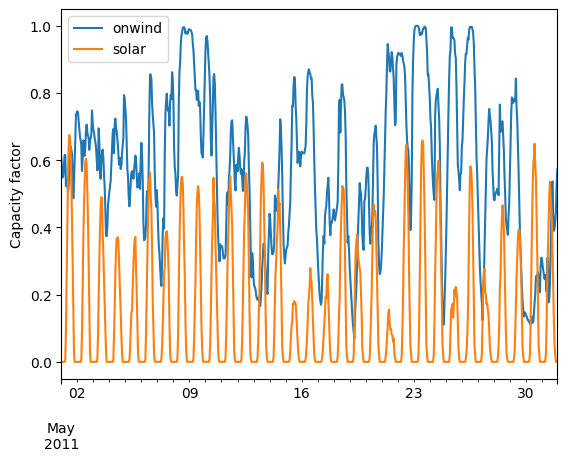

In [72]:
df.loc['05-2011'].plot(ylabel='Capacity factor')

<Axes: >

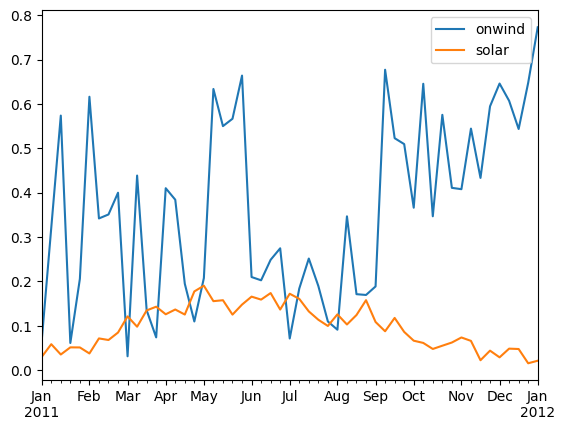

In [73]:
df.resample('W').mean().plot()